**Previously on:** Lecture 19 fit a line to steels data and reported R² -- a number computed
on the *same* data the line was fit to. Today asks the question that number quietly dodges:
does a fit that looks good on data it's already seen tell you anything about the next alloy?

Today's topics:
* why fitting error flatters a model
* train/test splitting: score only on data the model never saw
* overfitting, made visible by cranking up polynomial degree until it happens
* cross-validation as the honest average of several splits

This is still curve fitting, not a new subject -- just curve fitting done responsibly.

> By the end of today you should be able to run the polynomial-degree study Homework 7 asks
> for and describe, from the error curves alone, where overfitting begins.

# Section 1 -- our fit looked great. Did it?

## Dataset: Steel Alloy Compositions and Mechanical Properties

This dataset contains elemental compositions and mechanical properties of 915 steel alloys.

Composition columns (in wt%): `C`, `Si`, `Mn`, `P`, `S`, `Ni`, `Cr`, `Mo`, `Cu`, `V`, `Al`, `N`, `Ceq`, `Nb + Ta`

Target columns: `0.2% Proof Stress (MPa)`, `Tensile Strength (MPa)`, `Elongation (%)`, `Reduction in Area (%)`

The `Alloy code` column contains labels like `A1`, `B3`, etc. We derive `alloy_family` (first letter only)
to get a small set of categorical labels useful for classification tasks (4 families: C, L, M, V, all >150 samples).

In [1]:
import os
import pandas as pd

_file = 'steels.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# derive alloy family label (first letter of alloy code)
data['Alloy family'] = [c[0] for c in data['Alloy code']]

# set up features (composition columns) and target
x = data.loc[:, ' C':'Nb + Ta']
y = data['Alloy family']
alloy_family = data['Alloy family']

print(f'{len(data)} samples, {x.shape[1]} composition features')
data.head()

915 samples, 14 composition features


,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


Same housekeeping as last lecture -- drop the row-626 data-entry error before doing anything
else, and this time regress on all 14 composition columns at once instead of a single pair:

In [2]:
data = data.drop(index=626)
x = data.loc[:, ' C':'Nb + Ta']
y = data[' 0.2% Proof Stress (MPa)']

In [3]:
import numpy as np


class LinearModel:
    """Wraps lstsq-fitted coefficients with a .predict() method, so we can keep reusing
    evaluate_model()/plot_model() below just like we would with any fitted model object."""

    def __init__(self, coeffs):
        self.coeffs = coeffs

    def predict(self, x):
        X = np.column_stack([np.ones(len(x)), np.asarray(x)])
        return X.dot(self.coeffs)  # .dot, not @ -- avoids a spurious Accelerate-BLAS warning


def fit_linear(x, y):
    "Least-squares fit with an intercept column, via np.linalg.lstsq."
    X = np.column_stack([np.ones(len(x)), np.asarray(x)])
    coeffs, *_ = np.linalg.lstsq(X, np.asarray(y), rcond=None)
    return LinearModel(coeffs)


model = fit_linear(x, y)
y_pred = model.predict(x)
sse = np.sum((y.to_numpy() - y_pred) ** 2)
sst = np.sum((y.to_numpy() - y.mean()) ** 2)
r2 = 1 - sse / sst
print(f'R² on the data we fit to: {r2:.3f}')

R² on the data we fit to: 0.618


`np.linalg.lstsq` finds the coefficients that minimize SSE over all 14 composition columns at
once -- we let code find the best coefficients, same idea as `linregress`, just many slopes
instead of one. We wrap the result in a tiny object with a `.predict()` method so the rest of
today's tools can treat it just like any fitted model -- you'll meet this exact `.fit()` /
`.predict()` shape again with `scipy.curve_fit` in Lecture 22.

R² ≈ 0.62 -- noticeably better than any single-column fit from last lecture, because 14
composition columns carry more information than one. But ask the harder question: **is this
number telling us how good the model will be on the *next* alloy someone brings us?**

It can't be -- we scored the model on the exact rows it used to learn its coefficients.
**Fitting error tells you how well the model memorized these points; it does not tell you how
well it predicts new ones.**

# Section 2 -- why fit error flatters the model

A small, honest demonstration. Eight noisy points from a straight-line relationship, fit with
a line, a cubic, and a degree-7 polynomial:

degree 1: SSE on these 8 points = 242.17
degree 3: SSE on these 8 points = 133.45
degree 7: SSE on these 8 points = 0.00


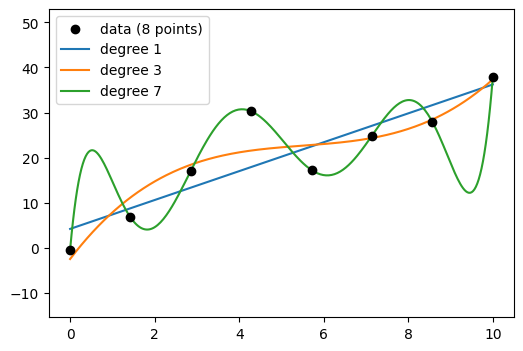

In [4]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(219)
x8 = np.linspace(0, 10, 8)
y8 = 3 * x8 + 5 + rng.normal(0, 4, size=8)

xx8 = np.linspace(0, 10, 300)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x8, y8, color='k', zorder=5, label='data (8 points)')
for deg, color in [(1, 'C0'), (3, 'C1'), (7, 'C2')]:
    c = np.polyfit(x8, y8, deg)
    ax.plot(xx8, np.polyval(c, xx8), color=color, label=f'degree {deg}')
    sse = np.sum((y8 - np.polyval(c, x8)) ** 2)
    print(f'degree {deg}: SSE on these 8 points = {sse:.2f}')
ax.set_ylim(y8.min() - 15, y8.max() + 15)
ax.legend()
plt.show()

The degree-7 curve threads every single point exactly -- SSE = 0, because a degree-7
polynomial has exactly enough free parameters (8) to hit 8 points exactly, no matter what
they are. **While the number of parameters equals or exceeds the number of points, there are
coefficient choices that hit R² = 1** -- that's not a discovery about this data, it's a fact
about algebra. And yet: which curve would you actually trust to predict a 9th point? The line,
not the wild degree-7 swing between points.

Two failure modes worth naming precisely:
* **Underfitting** -- model too simple, misses real trends (high error on *both* fit and new
  data).
* **Overfitting** -- model too flexible, chases noise instead of trend (low error on data it
  saw, high error on new data).

`np.linalg.lstsq`, `curve_fit`, `np.polyfit` -- every fitting tool you'll ever call always
reduces fitting error given more free parameters, because that is *what optimization does*.
Fitting error alone can never tell you when an extra parameter has started hurting you.
Even a perfect, true model of reality still has nonzero error on real measurements --
measurement noise alone guarantees that. A model with *zero* fitting error is not a sign
you found the truth; it's a sign you ran out of data to disagree with it.

# Section 3 -- train/test split

The fix: hold out data the model never sees while fitting, then score only on that held-out
set.

## Train/Test Split

In order to evaluate the performance of a model on unseen data, we need
to *hold out* some data. This will be called the **test** data.
The data used to fit will be called the **training** data.

As we use more sophisticated models, it is vitally important that we
evaluate our models in this way to avoid *overfitting*.
Remember that a model with enough degrees of freedom can perfectly fit
any data, but it won't have any predictive power!

```
all data:    [########################################################]
shuffle, then slice into two pieces:
train (75%): [##########################################]
test  (25%):                                              [##########]
```

We shuffle the *indices* once, then slice both `x` and `y` with that same shuffled order --
so a row's features and its target always stay paired.

In [5]:
import numpy as np

# split indices rather than data -- more flexible
rng = np.random.default_rng(0)
shuffled = rng.permutation(data.index)
n_test = int(np.ceil(0.25 * len(shuffled)))
idx_test = shuffled[:n_test]
idx_train = shuffled[n_test:]

xtrain = x.loc[idx_train]
xtest  = x.loc[idx_test]

ytrain = y.loc[idx_train]
ytest  = y.loc[idx_test]

print(f"Train: {xtrain.shape[0]} samples, Test: {xtest.shape[0]} samples")

Train: 685 samples, Test: 229 samples


We shuffle `data.index` once and slice both `x` and `y` with the *same* shuffled indices --
not two independent shuffles of `x` and `y` separately, which would desync which row's
features go with which row's target. Slicing once with shared indices is the same reasoning
behind every `.loc[mask]` filter since Lecture 11. The default split is 75% train / 25% test,
and seeding the shuffle (`np.random.default_rng(0)`) makes it reproducible: rerun the cell,
get the same split. Change the seed and a different quarter of alloys lands in test -- worth
remembering for Section 6.

Re-fit, but now **only** on the training rows:

In [6]:
model = fit_linear(xtrain, ytrain)

# Section 4 -- scoring honestly with `eval_helpers`

Two small functions we'll reuse for every model for the rest of this module:

## Convenience Functions

We'll set up some convenience functions for evaluating and visualizing
model performance so we don't have to repeat the same code for every model.

In [7]:
import matplotlib.pyplot as plt


def calc_rmse(model, X, y):
    "Calculate the RMSE from a fitted model."
    y_pred = model.predict(X)
    residuals = y_pred - y
    return np.sqrt(np.mean(residuals**2))


def evaluate_model(model, xtrain, xtest, ytrain, ytest):
    "Evaluate model performance on train and test set, then print the results."
    for name, xi, yi in [('train', xtrain, ytrain), ('test', xtest, ytest)]:
        y_pred = model.predict(xi)
        residuals = y_pred - yi
        # SSE-based, not Var(residuals)-based: Var() silently re-centers on the residual mean,
        # which is ~0 on training data (by construction, for a least-squares fit) but can be far
        # from 0 on held-out data -- inflating R2 exactly when it matters most (test-set scoring).
        sse = np.sum(residuals**2)
        sst = np.sum((yi - yi.mean())**2)
        r2 = 1 - sse / sst
        rmse = np.sqrt(np.mean(residuals**2))
        print(f'{name:5s}: Rsq = {r2:.3f}, RMSE = {rmse:.3f}')


def plot_model(model, xtrain, xtest, ytrain, ytest):
    "Create a parity plot using a trained model with train/test split."
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(ytrain, model.predict(xtrain), '.', label='Training Data')
    ax.plot(ytest, model.predict(xtest), '.', label='Testing Data')
    # min/max come from ytrain/ytest -- the arguments actually passed in -- never a global `y`.
    # Reaching out to a global here would be the exact scope anti-pattern Lecture 14's
    # bad_zscore example warned against.
    lo = min(np.min(ytrain), np.min(ytest))
    hi = max(np.max(ytrain), np.max(ytest))
    min_max = np.array([lo, hi])
    ax.plot(min_max, min_max, 'k--', label='Parity')
    ax.set_aspect('equal')
    ax.set_xlabel('Observation')
    ax.set_ylabel('Prediction')
    ax.legend()

In [8]:
evaluate_model(model, xtrain, xtest, ytrain, ytest)

train: Rsq = 0.622, RMSE = 80.956
test : Rsq = 0.596, RMSE = 83.195


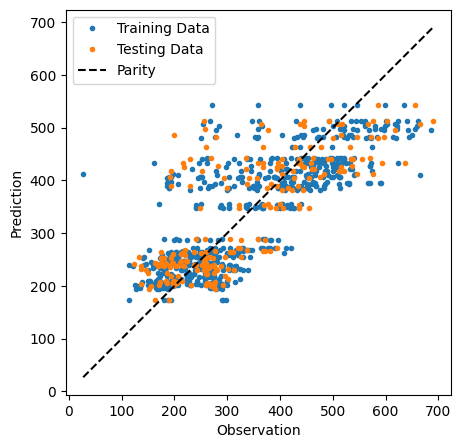

In [9]:
plot_model(model, xtrain, xtest, ytrain, ytest)

Train R² is a bit better than test R² -- expected, and healthy, not a red flag by itself. In
the parity plot, the orange test points scatter around the diagonal about as tightly as the
blue training points; if the model were badly overfit, the blue points would hug the diagonal
while the orange ones scattered widely. Keep that picture in mind -- Section 5 is about to
make it happen on purpose.

# Section 5 -- overfitting live: cranking polynomial degree

Switch to a single feature -- chromium content -- so the overfitting can be *seen* as a
wiggling curve, not just read off a number.

Here's an honest surprise from testing this demo against the real data first: **on the full
~685-row training set, a single feature does not overfit dramatically, even out to degree
15** -- 685 points heavily constrain even a high-degree polynomial. Overfitting-until-it-
explodes is a **small-sample** phenomenon, not a full-dataset one. So we deliberately shrink
the training set to 20 points for this one demo -- on purpose, to make a real phenomenon
visible that's usually subtler. HW7 will have you check whether it shows up at full scale
too.

In [10]:
def rmse(y_true, y_hat):
    return np.sqrt(np.mean((np.asarray(y_true) - y_hat) ** 2))


x1 = data[' Cr']                # single feature -- np.polyfit needs no 2D column shape
x1test = x1.loc[idx_test]

small_idx = idx_train[:20]      # deliberately tiny training set for this demo
x1small, ysmall = x1.loc[small_idx], y.loc[small_idx]

degrees = [1, 2, 3, 5, 8, 10, 12]
train_rmse, test_rmse = [], []
for d in degrees:
    c = np.polyfit(x1small, ysmall, d)
    train_rmse.append(rmse(ysmall, np.polyval(c, x1small)))
    test_rmse.append(rmse(ytest, np.polyval(c, x1test)))

for d, tr, te in zip(degrees, train_rmse, test_rmse):
    print(f'degree {d:2d}:  train RMSE = {tr:9.2f}   test RMSE = {te:14.2f}')

degree  1:  train RMSE =     93.44   test RMSE =         131.36
degree  2:  train RMSE =     87.34   test RMSE =         128.81
degree  3:  train RMSE =     87.10   test RMSE =         128.30
degree  5:  train RMSE =     84.97   test RMSE =         176.88
degree  8:  train RMSE =     72.78   test RMSE =       12514.97
degree 10:  train RMSE =     55.99   test RMSE =     1799995.73
degree 12:  train RMSE =     55.24   test RMSE =  2912668647.13


Train RMSE creeps steadily down as degree increases -- the model *can* fit these 20 points
better and better. Test RMSE is already higher than train RMSE at degree 1 -- that gap alone
isn't the warning sign, it's normal and expected. The signal to watch is the gap *growing* as
degree increases: test RMSE wiggles non-monotonically for the first few degrees (a real
feature of this particular 20-point sample, not a bug) before it breaks away and grows by
orders of magnitude. One honest caveat: past about degree 10, this fit is so close to
numerically singular that the *exact* blown-up number is sensitive to floating-point noise --
rerun this cell, or run it on a different machine, and the precise degree-12 value may differ,
sometimes by a lot. That instability is itself part of the lesson: an overfit model isn't just
inaccurate, it can become numerically meaningless.

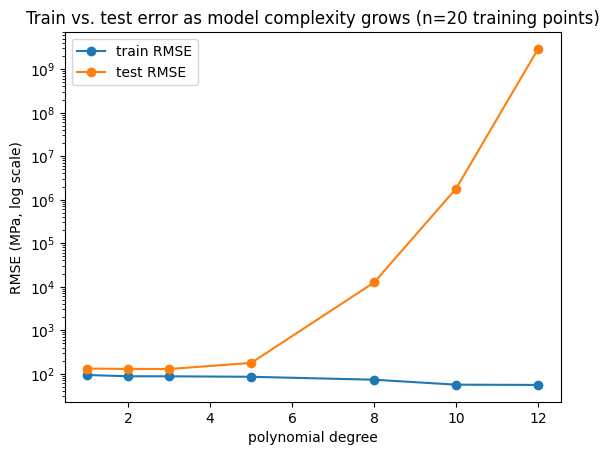

In [11]:
plt.plot(degrees, train_rmse, 'o-', label='train RMSE')
plt.plot(degrees, test_rmse, 'o-', label='test RMSE')
plt.yscale('log')
plt.xlabel('polynomial degree'); plt.ylabel('RMSE (MPa, log scale)')
plt.legend()
plt.title('Train vs. test error as model complexity grows (n=20 training points)')
plt.show()

The money shot: overlay the best-looking and worst-looking fits on the actual scatter.

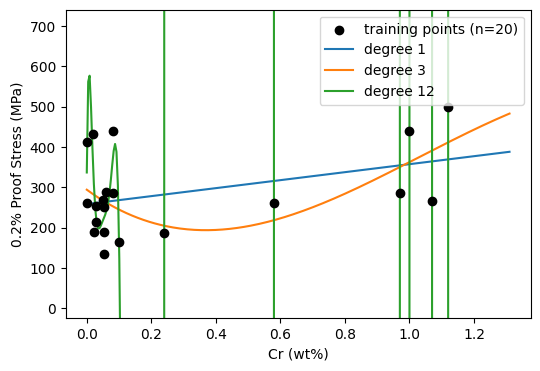

In [12]:
best_deg = degrees[int(np.argmin(test_rmse))]
xx1 = np.linspace(x1.min(), x1.max(), 300)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x1small, ysmall, color='k', zorder=5, label='training points (n=20)')
for d, color in [(1, 'C0'), (best_deg, 'C1'), (12, 'C2')]:
    c = np.polyfit(x1small, ysmall, d)
    ax.plot(xx1, np.polyval(c, xx1), color=color, label=f'degree {d}')
ax.set_ylim(y.min() - 50, y.max() + 50)
ax.set_xlabel('Cr (wt%)'); ax.set_ylabel('0.2% Proof Stress (MPa)')
ax.legend()
plt.show()

The degree-12 curve whips wildly between the 20 training points, especially near the edges of
the Cr range where points are sparse -- exactly the visual signature of memorizing noise
instead of learning a trend.

**The model with the best training score is not the model you want; the model with the best
test score is -- and this failure mode gets *worse*, not better, the less data you have.**

# Section 6 -- one split isn't enough: cross-validation (brief)

That single 75/25 split back in Section 3 was one arbitrary draw. A different shuffle seed
would have put different alloys in test and shifted the numbers. **k-fold cross-validation**
resolves this: shuffle once, cut into k equal folds, and rotate which fold plays test while
the rest play train -- average the test RMSE over all k rotations so no single unlucky split
misleads you. Mention-level today -- it's a direct extension of Section 3's split, not a new
idea.

In [13]:
# [Designated cut if class runs long -- Section 6 is mention-level, one compact cell.]
k = 5
rng = np.random.default_rng(0)
folds = np.array_split(rng.permutation(data.index), k)

fold_rmse = []
for i in range(k):
    fold_test = folds[i]
    fold_train = np.concatenate([folds[j] for j in range(k) if j != i])
    fold_model = fit_linear(x.loc[fold_train], y.loc[fold_train])
    fold_rmse.append(calc_rmse(fold_model, x.loc[fold_test], y.loc[fold_test]))

fold_rmse = np.array(fold_rmse)
print(f'CV RMSE: {fold_rmse.mean():.2f} +/- {fold_rmse.std():.2f}')

CV RMSE: 82.74 +/- 4.21


Compare that mean to Section 4's single-split test RMSE: close, but the spread across the 5
folds is the honest warning that one split alone could easily have read meaningfully better
or worse just by chance of which alloys landed in test. We will not go further into automated
model-selection machinery (`GridSearchCV` and friends) -- out of scope. The point today: cross-
validation is a more honest number than one train/test split, full stop.

## [Check your understanding]

Looking back at Section 5's table: at which degree does test RMSE first become clearly worse
than train RMSE, rather than tracking it? Is that also the degree with the single lowest test
RMSE? If not, which one would you actually pick to use on a new alloy, and why?

# Wrap-up

* **Fit error vs. test error**: a model's error on the data it was fit to always flatters it;
  only error on held-out data tells you how it will do on new alloys.
* **Overfitting vs. underfitting**: too few parameters misses real trends; too many chases
  noise -- and more parameters *always* lowers fitting error, so fitting error alone can never
  catch this.
* **Cross-validation** is the honest average of several train/test splits, with its spread
  telling you how much to trust any single split.
* Still no new branding here -- this is curve fitting from Lecture 19, evaluated responsibly.

**Take-home message:** never trust a model's score on the data it was trained on -- always
hold out data it never saw, and average over more than one split before you believe the
number.

For HW7: run this exact degree-cranking study yourselves, on a different single feature and
degree range, plot train/test RMSE vs. degree, and write one sentence identifying where
overfitting begins and why. `eval_helpers.py` and `split_train_test.py` are importable as-is
-- you should not need to write RMSE or parity-plot code from scratch.

Next class: worked examples pulling Lectures 19-20 together on a fresh column pair, including
one deliberately overfit model you'll have to diagnose yourselves -- then Quiz 4.